# Solution: A First Look at Data — Palmer Penguins

**Exercises from notebook `01_first_look_at_data.ipynb`**

Jingxu Li - 320230942071


## Exercise 1: Profile from Scratch

Using only `head()`, `shape`, and `info()`, write a 3-bullet "data dictionary": (a) how many records there are, (b) which columns are measurements vs. labels, and (c) which columns you suspect are missing data — guessing from `info()` before you run any `isnull` count. Then verify your missing-data guess with `df.isnull().sum()`.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../dataset/penguins.csv')
print("Shape:", df.shape)
df.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Based on `info()`, the Non-Null counts suggest: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` each have 2 missing values (344 − 342 = 2); `sex` has 11 missing values (344 − 333 = 11).

In [17]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

**Answer:**

(a) There are 344 records in the dataset.

(b) Measurement columns: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`. Label columns: `species`, `island`, `sex`.

(c) Based on `info()`, the Non-Null counts suggest: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` each have 2 missing values (344 − 342 = 2); `sex` has 11 missing values (344 − 333 = 11). The `isnull().sum()` verification confirms these counts exactly.


## Exercise 2: Don't Trust `head` Alone

Run `df.head()`, `df.tail()`, and `df.sample(5)`. Why can `head()` give a misleading first impression of a dataset? Name one thing visible in `tail` or `sample` that `head` hides.


In [18]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [19]:
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,MALE


In [21]:
df.sample(5, random_state=42)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
194,Chinstrap,Dream,50.9,19.1,196.0,3550.0,MALE
157,Chinstrap,Dream,45.2,17.8,198.0,3950.0,FEMALE
225,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,FEMALE
208,Chinstrap,Dream,45.2,16.6,191.0,3250.0,FEMALE
318,Gentoo,Biscoe,48.4,14.4,203.0,4625.0,FEMALE


**Answer:**

`head()` gives a misleading first impression because real datasets are often sorted — the first rows may contain only one species (e.g., Adelie from Torgersen), hiding the full diversity of the data. Something `sample()` reveals that `head()` hides: Chinstrap and Gentoo species appear in `sample()` but might be completely absent from `head()` when the dataset is sorted by species.


## Exercise 3: Read Shape from the Summary

From `describe()`, compare the mean and median of `body_mass_g`. Are they close, and what does that say about the distribution's shape? Then find one column whose `min` or `max` looks biologically implausible, and say how you would check whether it's a real value or an error.


In [22]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [24]:
mean_mass = df['body_mass_g'].mean()
median_mass = df['body_mass_g'].median()
print(f"Mean body_mass_g: {mean_mass:.1f} ")
print(f"Median body_mass_g: {median_mass:.1f} ")
print(f"Difference: {mean_mass - median_mass:.1f} ")

Mean body_mass_g: 4201.8 
Median body_mass_g: 4050.0 
Difference: 151.8 


In [26]:
for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']:
    print(f"{col:20s}: min = {df[col].min():8.1f}, max = {df[col].max():8.1f}")

bill_length_mm      : min =     32.1, max =     59.6
bill_depth_mm       : min =     13.1, max =     21.5
flipper_length_mm   : min =    172.0, max =    231.0
body_mass_g         : min =   2700.0, max =   6300.0


**Answer:**

The mean (4201.8 g) is larger than the median (4050.0 g) by about 152 g, indicating the distribution is **right-skewed** — a heavier tail toward higher body mass values.

Among the numeric columns, all min/max values fall within biologically plausible ranges for penguin species (bill: 32–60 mm, flipper: 172–231 mm, body mass: 2700–6300 g). To check a suspicious value, I would examine the entire row for that penguin — if other measurements are consistent with the same individual, the value is likely real; if multiple columns look anomalous, it may be a data entry error.


## Exercise 4: Counts Have Consequences

Count the penguins of each species. The groups are uneven — is that a problem? Describe one later analysis where unequal group sizes could quietly mislead you.


In [27]:
df['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

**Answer:**

Adelie = 152, Gentoo = 124, Chinstrap = 68. The groups are clearly uneven, with Chinstrap having fewer than half the penguins of Adelie. This can be a problem: when comparing group means (e.g., body mass by species via ANOVA), Chinstrap's smaller sample gives it a wider confidence interval, meaning a true difference involving Chinstrap might fail to reach statistical significance — not because no difference exists, but because of insufficient sample size.


## Exercise 5: Missing Data, and What It Would Cost

Which columns have missing values, and how many each? If you dropped every row with any missing value, how many penguins would you lose — and is that loss spread evenly across species?


In [28]:
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")

df_dropped = df.dropna()
print(f"Rows remaining after dropna: {len(df_dropped)}")
print(f"Rows lost: {len(df) - len(df_dropped)}")

missing_rows = df[df.isnull().any(axis=1)]
print("\nMissing rows by species:")
print(missing_rows['species'].value_counts())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Total rows: 344
Rows remaining after dropna: 333
Rows lost: 11

Missing rows by species:
species
Adelie    6
Gentoo    5
Name: count, dtype: int64


**Answer:**

Columns with missing values: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` (2 each), and `sex` (11 missing — the most). Dropping all rows with any NaN removes 11 penguins. The loss is **not evenly distributed**: Adelie loses 6, Gentoo loses 5, and Chinstrap loses 0. This biased loss means dropping rows would systematically under-represent Adelie and Gentoo, making the approach unsafe for any species-level analysis.


## Exercise 6: Where Do the Species Live?

Which species was seen on all three islands, and which two each live on only one?


In [29]:
ct = pd.crosstab(df['species'], df['island'])
ct

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


**Answer:**

**Adelie** was seen on all three islands (Biscoe, Dream, Torgersen). **Gentoo** lives only on Biscoe (124 penguins). **Chinstrap** lives only on Dream (68 penguins).


## Exercise 7: Quick Histogram

Make a quick histogram of `body_mass_g`. Does it look like one smooth hump, or can you already see signs of hidden groups? Write one sentence describing what you see.


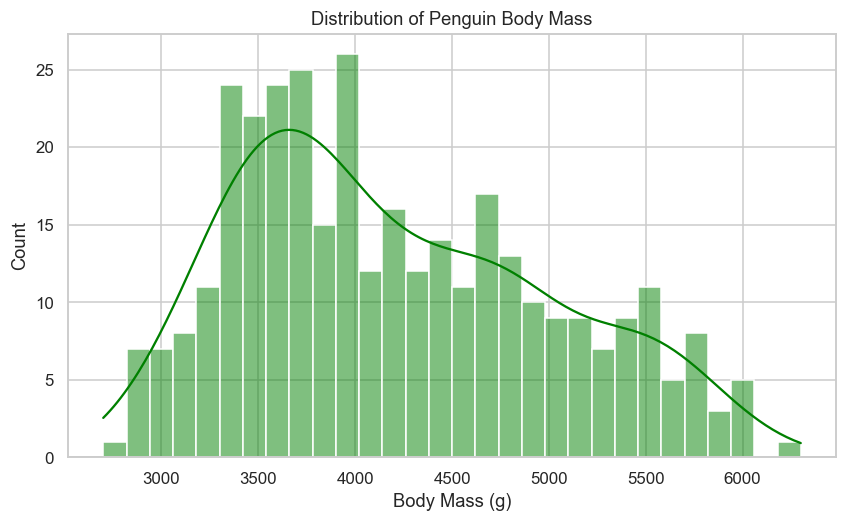

In [34]:
plt.figure(figsize=(9, 5))
sns.histplot(df['body_mass_g'].dropna(), bins=30, kde=True, color='green')
plt.title('Distribution of Penguin Body Mass')
plt.xlabel('Body Mass (g)')
plt.ylabel('Count')
plt.show()

**Answer:**

The histogram does not look like one smooth hump — it shows multiple peaks and a broad spread, suggesting that the data contains hidden groups (different species) mixed together, which will be explored further in upcoming notebooks.
